# 🦾 Control de Brazo Robótico con Aprendizaje por Refuerzo
### Deep Deterministic Policy Gradient (DDPG) + TensorFlow 2.x

---

**Autor:** Nicolás García Hernández
**Fecha:** Marzo 2026
**Asignatura:** Inteligencia Artificial

---

## 📋 Descripción del Proyecto

En este proyecto se implementa un sistema de **Aprendizaje por Refuerzo (RL)** para
controlar un **brazo robótico simulado en 2D con 3 articulaciones** (hombro, codo y muñeca).
El objetivo es entrenar un agente inteligente para que aprenda, por sí solo, a mover
el efector final del brazo hasta alcanzar posiciones objetivo generadas aleatoriamente.

## 🧠 Algoritmo: DDPG
Se utiliza el algoritmo **Deep Deterministic Policy Gradient**, especialmente adecuado
para robótica porque trabaja con **espacios de acción continuos** (torques angulares reales),
a diferencia del Q-Learning clásico que solo funciona con acciones discretas.

## 🗂️ Estructura del Notebook

| # | Sección | Descripción |
|---|---|---|
| 1 | Marco Teórico | Fundamentos del Aprendizaje por Refuerzo |
| 2 | Hiperparámetros | Configuración centralizada del experimento |
| 3 | Instalación | Librerías e imports necesarios |
| 4 | Entorno simulado | Definición del brazo robótico y su física |
| 5 | Componentes DDPG | Replay Buffer, Ruido OU, Redes Actor y Critic |
| 6 | Agente DDPG | Integración completa del agente |
| 7 | Entrenamiento | Bucle principal de aprendizaje |
| 8 | Métricas | Visualización del progreso del entrenamiento |
| 9 | Evaluación | Análisis exhaustivo del agente entrenado |
| 10 | Visualización | Representación gráfica del brazo en acción |
| 11 | Conclusiones | Observaciones e insights del comportamiento |

## 📚 1. Marco Teórico: Aprendizaje por Refuerzo

El **Aprendizaje por Refuerzo (RL)** es una rama del aprendizaje automático donde un
**agente** aprende a tomar decisiones interactuando con un **entorno**, con el objetivo
de maximizar una señal de **recompensa** acumulada a lo largo del tiempo.

---

### 🔁 El Ciclo Agente–Entorno


En cada paso de tiempo `t` el ciclo es:
1. El agente observa el **estado** actual `s_t`
2. Elige una **acción** `a_t` según su política `π(a|s)`
3. El entorno transiciona al **nuevo estado** `s_{t+1}`
4. El agente recibe una **recompensa** `r_t`
5. El agente **actualiza su política** para mejorar decisiones futuras

---

### 🧩 Componentes Clave del RL

| Componente | Definición general | Rol en este proyecto |
|---|---|---|
| **Agente** | Entidad que aprende y toma decisiones | Red neuronal DDPG |
| **Entorno** | Sistema con el que interactúa el agente | Brazo robótico 2D simulado |
| **Estado (s)** | Representación de la situación actual | Ángulos + distancia al objetivo (6 valores) |
| **Acción (a)** | Decisión tomada por el agente | Torque en cada articulación (3 valores continuos) |
| **Recompensa (r)** | Señal de retroalimentación del entorno | `-distancia + bonus éxito - penalizaciones` |
| **Política (π)** | Estrategia que mapea estados a acciones | Red Actor del DDPG |
| **Función Q** | Valor esperado de tomar acción `a` en estado `s` | Red Critic del DDPG |

---

### 📐 Proceso de Decisión de Markov (MDP)

El problema se formula como un **MDP** definido por la tupla `(S, A, T, R, γ)`:
- `S` → Espacio de estados: vectores de dimensión 6
- `A` → Espacio de acciones continuas: vectores de dimensión 3 en `[-1, 1]`
- `T` → Función de transición: cinemática directa del brazo
- `R` → Función de recompensa: distancia + bonus de éxito
- `γ = 0.99` → Factor de descuento (cuánto valoramos recompensas futuras)

---

### 🧮 Ecuación de Optimalidad de Bellman

El algoritmo DDPG se basa en esta ecuación fundamental:

$$Q^*(s, a) = \mathbb{E}\left[r + \gamma \max_{a'} Q^*(s', a')\right]$$

Expresa que el valor Q óptimo de tomar la acción `a` en el estado `s` es igual a la
recompensa inmediata más el valor futuro descontado. La red Critic aprende a aproximar
esta función iterativamente.

---

### 🎯 ¿Por qué DDPG y no Q-Learning?

| Algoritmo | Tipo de acción | Adecuado para robótica |
|---|---|---|
| Q-Learning / DQN | Discreta (0°, 10°, 20°...) | ❌ Poca precisión |
| DDPG | Continua (cualquier torque real) | ✅ Alta precisión |
| PPO | Continua o discreta | ✅ Alternativa válida |

DDPG resuelve el espacio continuo combinando:
- **Actor:** Política determinista `μ(s)` → produce acción continua directamente
- **Critic:** Evalúa `Q(s,a)` para guiar el aprendizaje del Actor
- **Experience Replay + Redes Objetivo:** Estabilizan el entrenamiento evitando oscilaciones


## ⚙️ 2. Configuración de Hiperparámetros

Todos los hiperparámetros del experimento están centralizados en el diccionario `CONFIG`.
Esto facilita la **reproducibilidad** del experimento y permite modificar cualquier
parámetro sin tocar el resto del código. Cada valor está justificado con un comentario.


In [9]:
# ============================================================
# CONFIGURACIÓN CENTRALIZADA DE HIPERPARÁMETROS
# Modificar aquí para experimentar con distintas configuraciones
# ============================================================

CONFIG = {
    # ── Entorno ──────────────────────────────────────────────
    'link_lengths'      : [1.0, 0.8, 0.6],  # Longitudes de cada segmento del brazo
    'max_angular_vel'   : 0.1,               # Velocidad angular máxima (rad/paso)
    'success_threshold' : 0.15,              # Distancia mínima para considerar éxito
    'max_steps_episode' : 200,               # Pasos máximos por episodio

    # ── Entrenamiento ─────────────────────────────────────────
    'n_episodes'        : 200,               # Episodios totales de entrenamiento
    'warmup_steps'      : 1000,              # Pasos iniciales con acciones aleatorias
    'batch_size'        : 64,                # Tamaño del mini-batch para el gradiente
    'buffer_size'       : 100_000,           # Capacidad máxima del Replay Buffer

    # ── Redes Neuronales ──────────────────────────────────────
    'actor_lr'          : 1e-4,              # Learning rate del Actor
    'critic_lr'         : 2e-4,              # Learning rate del Critic
    'gamma'             : 0.99,              # Factor de descuento de recompensas futuras
    'tau'               : 0.005,             # Tasa de actualización suave (soft update)

    # ── Exploración: Ruido Ornstein-Uhlenbeck ─────────────────
    'ou_theta'          : 0.15,              # Velocidad de reversión a la media
    'ou_sigma'          : 0.2,               # Magnitud inicial del ruido
    'ou_sigma_min'      : 0.05,              # Magnitud mínima tras decaimiento
    'ou_sigma_decay'    : 0.998,             # Factor de decaimiento por episodio

    # ── Reproducibilidad ─────────────────────────────────────
    'seed_numpy'        : 42,
    'seed_tf'           : 42,
}

print("⚙️  Configuración del experimento cargada:")
print("─" * 48)
for key, val in CONFIG.items():
    print(f"  {key:<22} : {val}")
print("─" * 48)
print("✅ CONFIG listo")


⚙️  Configuración del experimento cargada:
────────────────────────────────────────────────
  link_lengths           : [1.0, 0.8, 0.6]
  max_angular_vel        : 0.1
  success_threshold      : 0.15
  max_steps_episode      : 200
  n_episodes             : 200
  warmup_steps           : 1000
  batch_size             : 64
  buffer_size            : 100000
  actor_lr               : 0.0001
  critic_lr              : 0.0002
  gamma                  : 0.99
  tau                    : 0.005
  ou_theta               : 0.15
  ou_sigma               : 0.2
  ou_sigma_min           : 0.05
  ou_sigma_decay         : 0.998
  seed_numpy             : 42
  seed_tf                : 42
────────────────────────────────────────────────
✅ CONFIG listo


## 📦 3. Instalación y Librerías

Se importan todas las librerías necesarias para el proyecto. Google Colab incluye
**TensorFlow, NumPy y Matplotlib** preinstalados, por lo que no se requiere
ninguna instalación adicional.

Se verifica también la disponibilidad de **GPU**, que aceleraría el entrenamiento,
aunque el proyecto está optimizado para funcionar correctamente en CPU.


In [10]:
# ============================================================
# APRENDIZAJE POR REFUERZO — CONTROL DE BRAZO ROBÓTICO 2D
# Algoritmo  : DDPG (Deep Deterministic Policy Gradient)
# Framework  : TensorFlow 2.x
# Autor      : Nicolás García Hernández
# Fecha      : Marzo 2026
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import deque
import random
import time

np.random.seed(CONFIG['seed_numpy'])
tf.random.set_seed(CONFIG['seed_tf'])

print(f"✅ TensorFlow  : {tf.__version__}")
print(f"✅ NumPy       : {np.__version__}")
print(f"🖥️  GPU disponible: {tf.config.list_physical_devices('GPU')}")
print("✅ Semillas de reproducibilidad fijadas")


✅ TensorFlow  : 2.19.0
✅ NumPy       : 2.0.2
🖥️  GPU disponible: []
✅ Semillas de reproducibilidad fijadas


## 🤖 4. Entorno Simulado del Brazo Robótico

Se define el **entorno de simulación** del brazo robótico siguiendo la estructura
estándar de entornos RL:

- **`reset()`** → Reinicia el brazo y genera un nuevo objetivo aleatorio
- **`step(action)`** → Aplica un torque, devuelve nuevo estado y recompensa
- **`render_state()`** → Devuelve posiciones para visualización

### 📐 Cinemática Directa
La posición del efector final se calcula acumulando los ángulos de cada articulación.
Con 3 segmentos de longitudes 1.0, 0.8 y 0.6, el alcance máximo es **2.4 unidades**.

### 🏆 Sistema de Recompensas

| Componente | Valor | Propósito |
|---|---|---|
| Distancia al objetivo | `-distancia` | Guía principal hacia el objetivo |
| Éxito (dist < 0.15) | `+20` | Incentiva alcanzar el objetivo |
| Proximidad (dist < 0.30) | `+5` | Recompensa intermedia de acercamiento |
| Penalización acción brusca | `-0.01 × ∥a∥²` | Induce movimientos suaves |
| Penalización límite angular | `-0.5` | Evita bloqueos en los extremos |


In [11]:
class RoboticArmEnv:
    """
    Entorno simulado de un brazo robótico 2D con 3 articulaciones.

    ESTADO  (6 dim): ángulos normalizados (×3) + dx, dy, distancia al objetivo
    ACCIÓN  (3 dim): torque normalizado en [-1, 1] para cada articulación
    """

    def __init__(self, config=CONFIG):
        self.link_lengths      = config['link_lengths']
        self.n_joints          = len(self.link_lengths)
        self.max_reach         = sum(self.link_lengths)
        self.angle_limits      = [(-np.pi, np.pi)] * self.n_joints
        self.max_angular_vel   = config['max_angular_vel']
        self.success_threshold = config['success_threshold']
        self.max_steps         = config['max_steps_episode']
        self.state_dim         = 6
        self.action_dim        = 3
        self.reset()

    def reset(self):
        self.angles     = np.random.uniform(-np.pi/2, np.pi/2, self.n_joints)
        self.step_count = 0
        self.target     = self._generate_target()
        return self._get_state()

    def _generate_target(self):
        while True:
            angle  = np.random.uniform(0, 2 * np.pi)
            radius = np.random.uniform(0.5, self.max_reach * 0.85)
            target = np.array([radius * np.cos(angle), radius * np.sin(angle)])
            if np.linalg.norm(target) <= self.max_reach:
                return target

    def _forward_kinematics(self, angles=None):
        if angles is None: angles = self.angles
        positions        = [np.array([0.0, 0.0])]
        cumulative_angle = 0.0
        for length, angle in zip(self.link_lengths, angles):
            cumulative_angle += angle
            positions.append(positions[-1] + length * np.array([
                np.cos(cumulative_angle), np.sin(cumulative_angle)
            ]))
        return positions

    def _get_end_effector(self):
        return self._forward_kinematics()[-1]

    def _get_state(self):
        ee       = self._get_end_effector()
        dx       = self.target[0] - ee[0]
        dy       = self.target[1] - ee[1]
        distance = np.linalg.norm([dx, dy])
        return np.array([
            *(self.angles / np.pi),
            dx       / self.max_reach,
            dy       / self.max_reach,
            distance / self.max_reach
        ], dtype=np.float32)

    def step(self, action):
        self.step_count += 1
        action      = np.clip(action, -1.0, 1.0)
        self.angles = np.clip(
            self.angles + action * self.max_angular_vel,
            [l[0] for l in self.angle_limits],
            [l[1] for l in self.angle_limits]
        )
        ee       = self._get_end_effector()
        distance = np.linalg.norm(self.target - ee)
        reward   = self._compute_reward(distance, action)
        success  = distance < self.success_threshold
        done     = success or (self.step_count >= self.max_steps)
        return self._get_state(), reward, done, {
            'distance': distance, 'success': success,
            'step': self.step_count, 'end_effector': ee
        }

    def _compute_reward(self, distance, action):
        r  = -distance
        r += 20.0 if distance < self.success_threshold else \
              5.0 if distance < self.success_threshold * 2 else 0.0
        r += -0.01 * np.sum(np.square(action))
        r += -0.5  if np.any(np.abs(self.angles) >= np.pi * 0.95) else 0.0
        return r

    def render_state(self):
        return self._forward_kinematics(), self.target


# ── Test del entorno ──────────────────────────────────────────
env   = RoboticArmEnv()
state = env.reset()
_, r, _, info = env.step(np.random.uniform(-1, 1, env.action_dim))
print("✅ Entorno creado y testeado correctamente")
print(f"   Dimensión estado  : {env.state_dim}")
print(f"   Dimensión acción  : {env.action_dim}")
print(f"   Alcance máximo    : {env.max_reach} unidades")
print(f"   Recompensa test   : {r:.4f} | Distancia: {info['distance']:.4f}")


✅ Entorno creado y testeado correctamente
   Dimensión estado  : 6
   Dimensión acción  : 3
   Alcance máximo    : 2.4 unidades
   Recompensa test   : -1.6333 | Distancia: 1.6108


## 🧩 5. Componentes del Agente DDPG

### 🗃️ Replay Buffer
Almacena hasta 100.000 experiencias `(s, a, r, s', done)`. Durante el entrenamiento
se extraen muestras **aleatorias** para romper la correlación temporal entre
experiencias consecutivas, lo que estabiliza enormemente el aprendizaje.

### 〰️ Ruido Ornstein-Uhlenbeck (OU)
Genera ruido con **correlación temporal** para explorar el espacio de acciones
de forma suave. A diferencia del ruido gaussiano puro, el ruido OU produce
trayectorias continuas, mucho más adecuadas para sistemas físicos como robots.
Su magnitud decae gradualmente según `σ × 0.998` por episodio.

### 🎭 Red Actor  `estado → acción`
Red densa **256 → 256 → 128** con `LayerNormalization` para estabilidad.
Recibe el estado y produce torques angulares. La salida usa `tanh` para
mantener las acciones en `[-1, 1]`.

### ⚖️ Red Critic  `(estado, acción) → valor Q`
Recibe el estado y la acción por separado. El estado pasa por una primera capa
densa y luego **se fusiona con la acción** en la segunda capa, siguiendo la
arquitectura estándar de DDPG para estimar el valor Q correctamente.


In [12]:
# ── Replay Buffer ─────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, max_size=CONFIG['buffer_size']):
        self.buffer = deque(maxlen=max_size)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch        = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (np.array(s,  dtype=np.float32),
                np.array(a,  dtype=np.float32),
                np.array(r,  dtype=np.float32).reshape(-1, 1),
                np.array(ns, dtype=np.float32),
                np.array(d,  dtype=np.float32).reshape(-1, 1))

    def size(self): return len(self.buffer)


# ── Ruido Ornstein-Uhlenbeck ──────────────────────────────────
class OUNoise:
    def __init__(self, action_dim,
                 theta=CONFIG['ou_theta'], sigma=CONFIG['ou_sigma']):
        self.action_dim = action_dim
        self.mu    = 0.0
        self.theta = theta
        self.sigma = sigma
        self.state = np.zeros(action_dim)

    def reset(self):
        self.state = np.zeros(self.action_dim)

    def sample(self):
        dx = self.theta * (self.mu - self.state) + \
             self.sigma * np.random.randn(self.action_dim)
        self.state += dx
        return self.state


# ── Red Actor ─────────────────────────────────────────────────
def build_actor(state_dim, action_dim):
    inputs = tf.keras.Input(shape=(state_dim,), name='state_input')
    x = tf.keras.layers.Dense(256)(inputs)
    x = tf.keras.layers.LayerNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.layers.LayerNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dense(128)(x)
    x = tf.keras.layers.ReLU()(x)
    outputs = tf.keras.layers.Dense(
        action_dim, activation='tanh',
        kernel_initializer=tf.keras.initializers.RandomUniform(-3e-3, 3e-3),
        name='action_output'
    )(x)
    return tf.keras.Model(inputs, outputs, name='Actor')


# ── Red Critic ────────────────────────────────────────────────
def build_critic(state_dim, action_dim):
    s_in = tf.keras.Input(shape=(state_dim,),  name='state_input')
    a_in = tf.keras.Input(shape=(action_dim,), name='action_input')
    s = tf.keras.layers.Dense(256)(s_in)
    s = tf.keras.layers.LayerNormalization()(s)
    s = tf.keras.layers.ReLU()(s)
    x = tf.keras.layers.Concatenate()([s, a_in])
    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.layers.LayerNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dense(128)(x)
    x = tf.keras.layers.ReLU()(x)
    outputs = tf.keras.layers.Dense(
        1, kernel_initializer=tf.keras.initializers.RandomUniform(-3e-3, 3e-3),
        name='q_value'
    )(x)
    return tf.keras.Model([s_in, a_in], outputs, name='Critic')


print("✅ ReplayBuffer, OUNoise, Actor y Critic definidos")
print("\n📋 Arquitectura del Actor:")
build_actor(6, 3).summary()
print("\n📋 Arquitectura del Critic:")
build_critic(6, 3).summary()


✅ ReplayBuffer, OUNoise, Actor y Critic definidos

📋 Arquitectura del Actor:


Model: "Actor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ state_input (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 256)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_28          │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_42 (ReLU)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_29          │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_43 (ReLU)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_44 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ action_output (Dense)           │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,891 (398.01 KB)

 Trainable params: 101,891 (398.01 KB)

...

Model: "Critic"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ state_input         │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 256)       │      1,792 │ state_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256)       │        512 │ dense_45[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_45 (ReLU)     │ (None, 256)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ action_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 259)       │          0 │ re_lu_45[0][0],   │
│ (Concatenate)       │                   │            │ action_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 256)       │     66,560 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256)       │        512 │ dense_46[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_46 (ReLU)     │ (None, 256)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 128)       │     32,896 │ re_lu_46[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_47 (ReLU)     │ (None, 128)       │          0 │ dense_47[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_value (Dense)     │ (None, 1)         │        129 │ re_lu_47[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 102,401 (400.00 KB)

 Trainable params: 102,401 (400.00 KB)

 Non-trainable params: 0 (0.00 B)

## 🤖 6. Agente DDPG Completo

Se integran todos los componentes en la clase `DDPGAgent`.

### 🔑 Estrategia de Doble Red (Principal + Objetivo)
Cada red (Actor y Critic) tiene una copia "objetivo" que se actualiza
**lentamente** mediante actualización suave:


Esto evita que los valores objetivo cambien demasiado rápido, una de las
principales causas de inestabilidad en RL profundo.

### 📋 Flujo de entrenamiento por paso
1. Muestrear batch del Replay Buffer
2. Calcular **Q objetivo** con las redes objetivo
3. Actualizar **Critic** minimizando el error cuadrático con Q objetivo
4. Actualizar **Actor** maximizando el Q predicho por el Critic
5. Aplicar **soft update** a redes objetivo


In [13]:
class DDPGAgent:
    def __init__(self, state_dim, action_dim):
        self.gamma      = CONFIG['gamma']
        self.tau        = CONFIG['tau']
        self.batch_size = CONFIG['batch_size']

        # Redes principales (se actualizan con gradientes)
        self.actor  = build_actor(state_dim, action_dim)
        self.critic = build_critic(state_dim, action_dim)

        # Redes objetivo (se actualizan lentamente)
        self.actor_target  = build_actor(state_dim, action_dim)
        self.critic_target = build_critic(state_dim, action_dim)
        self.actor_target.set_weights(self.actor.get_weights())
        self.critic_target.set_weights(self.critic.get_weights())

        self.actor_optimizer  = tf.keras.optimizers.Adam(CONFIG['actor_lr'])
        self.critic_optimizer = tf.keras.optimizers.Adam(CONFIG['critic_lr'])
        self.replay_buffer    = ReplayBuffer()
        self.noise            = OUNoise(action_dim)

    def get_action(self, state, add_noise=True):
        s      = tf.expand_dims(tf.convert_to_tensor(state, dtype=tf.float32), 0)
        action = self.actor(s, training=False).numpy()[0]
        if add_noise:
            action += self.noise.sample()
        return np.clip(action, -1.0, 1.0)

    @tf.function
    def _train_step(self, states, actions, rewards, next_states, dones):
        # Calcular Q objetivo
        next_actions = self.actor_target(next_states, training=False)
        next_q       = self.critic_target([next_states, next_actions], training=False)
        target_q     = rewards + self.gamma * next_q * (1.0 - dones)

        # Actualizar Critic
        with tf.GradientTape() as tape:
            q_pred      = self.critic([states, actions], training=True)
            critic_loss = tf.reduce_mean(tf.square(target_q - q_pred))
        grads = tape.gradient(critic_loss, self.critic.trainable_variables)
        self.critic_optimizer.apply_gradients(
            zip(grads, self.critic.trainable_variables))

        # Actualizar Actor
        with tf.GradientTape() as tape:
            actions_pred = self.actor(states, training=True)
            actor_loss   = -tf.reduce_mean(
                self.critic([states, actions_pred], training=False))
        grads = tape.gradient(actor_loss, self.actor.trainable_variables)
        self.actor_optimizer.apply_gradients(
            zip(grads, self.actor.trainable_variables))

        return actor_loss, critic_loss

    def train(self):
        if self.replay_buffer.size() < self.batch_size:
            return
        s, a, r, ns, d = self.replay_buffer.sample(self.batch_size)
        self._train_step(
            tf.constant(s), tf.constant(a), tf.constant(r),
            tf.constant(ns), tf.constant(d)
        )
        self._soft_update(self.actor,  self.actor_target)
        self._soft_update(self.critic, self.critic_target)

    def _soft_update(self, source, target):
        target.set_weights([
            self.tau * sw + (1.0 - self.tau) * tw
            for sw, tw in zip(source.get_weights(), target.get_weights())
        ])

    def save(self, path='ddpg_arm'):
        self.actor.save_weights(f'{path}_actor.weights.h5')
        self.critic.save_weights(f'{path}_critic.weights.h5')
        print(f"💾 Modelo guardado → {path}_actor/critic.weights.h5")

    def load(self, path='ddpg_arm'):
        self.actor.load_weights(f'{path}_actor.weights.h5')
        self.critic.load_weights(f'{path}_critic.weights.h5')
        print(f"📂 Modelo cargado desde → {path}")


print("✅ Clase DDPGAgent definida correctamente")


✅ Clase DDPGAgent definida correctamente


## 🏋️ 7. Entrenamiento del Agente

El entrenamiento se divide en dos fases:

### Fase 1 — Warmup (1.000 pasos)
Antes de que el agente empiece a aprender, se llena el Replay Buffer con
experiencias generadas por **acciones completamente aleatorias**. Esto garantiza
diversidad inicial en los datos y evita que el agente aprenda de muestras
demasiado similares entre sí al inicio.

### Fase 2 — Episodios de Entrenamiento (400 episodios)
En cada episodio el agente:
1. Observa el estado del entorno
2. Elige una acción con **ruido OU** para fomentar la exploración
3. Ejecuta la acción, recibe la recompensa y almacena la experiencia
4. Entrena sus redes con un batch aleatorio del buffer
5. Repite hasta alcanzar el objetivo o llegar a 200 pasos

A medida que avanzan los episodios, el ruido se **reduce gradualmente**
(`σ × 0.998` por episodio), haciendo que el agente pase de explorar
a explotar su política aprendida. El progreso se imprime cada 20 episodios.


In [14]:
def train_agent():
    env   = RoboticArmEnv()
    agent = DDPGAgent(state_dim=env.state_dim, action_dim=env.action_dim)

    episode_rewards  = []
    distances_final  = []
    success_rate_log = []
    successes_window = deque(maxlen=50)

    print("=" * 63)
    print("    ENTRENAMIENTO DDPG — BRAZO ROBÓTICO 2D (3 ARTICULACIONES)")
    print("=" * 63)
    print(f"  Episodios        : {CONFIG['n_episodes']}")
    print(f"  Warmup steps     : {CONFIG['warmup_steps']}")
    print(f"  Batch size       : {CONFIG['batch_size']}")
    print(f"  Umbral de éxito  : distancia < {CONFIG['success_threshold']}")
    print("=" * 63)

    # ── Fase Warmup ───────────────────────────────────────────
    print("\n[Warmup] Llenando Replay Buffer con acciones aleatorias...")
    state = env.reset()
    for _ in range(CONFIG['warmup_steps']):
        action         = np.random.uniform(-1, 1, env.action_dim)
        ns, r, done, _ = env.step(action)
        agent.replay_buffer.add(state, action, r, ns, float(done))
        state = env.reset() if done else ns
    print(f"[Warmup] ✅ Completado — {agent.replay_buffer.size()} transiciones\n")

    start_time = time.time()

    # ── Bucle de Episodios ────────────────────────────────────
    for episode in range(1, CONFIG['n_episodes'] + 1):
        state     = env.reset()
        agent.noise.reset()
        ep_reward = 0.0

        while True:
            action                 = agent.get_action(state, add_noise=True)
            ns, reward, done, info = env.step(action)
            agent.replay_buffer.add(state, action, reward, ns, float(done))
            agent.train()
            state     = ns
            ep_reward += reward
            if done: break

        # Decaimiento del ruido de exploración
        agent.noise.sigma = max(CONFIG['ou_sigma_min'],
                                agent.noise.sigma * CONFIG['ou_sigma_decay'])

        episode_rewards.append(ep_reward)
        distances_final.append(info['distance'])
        successes_window.append(int(info['success']))
        success_rate_log.append(np.mean(successes_window) * 100)

        if episode % 20 == 0:
            elapsed = time.time() - start_time
            print(
                f"  Ep {episode:4d}/{CONFIG['n_episodes']} | "
                f"Recompensa: {np.mean(episode_rewards[-50:]):8.2f} | "
                f"Distancia: {np.mean(distances_final[-50:]):.4f} | "
                f"Éxito: {success_rate_log[-1]:5.1f}% | "
                f"Tiempo: {elapsed:5.0f}s"
            )

    print("\n✅ Entrenamiento completado")
    agent.save()

    return agent, env, {
        'rewards'      : episode_rewards,
        'distances'    : distances_final,
        'success_rate' : success_rate_log
    }


agent, env, metrics = train_agent()


    ENTRENAMIENTO DDPG — BRAZO ROBÓTICO 2D (3 ARTICULACIONES)
  Episodios        : 200
  Warmup steps     : 1000
  Batch size       : 64
  Umbral de éxito  : distancia < 0.15

[Warmup] Llenando Replay Buffer con acciones aleatorias...
[Warmup] ✅ Completado — 1000 transiciones

  Ep   20/200 | Recompensa:  -344.52 | Distancia: 1.2715 | Éxito:  15.0% | Tiempo:   149s
  Ep   40/200 | Recompensa:  -309.35 | Distancia: 1.2093 | Éxito:  12.5% | Tiempo:   293s
  Ep   60/200 | Recompensa:  -318.14 | Distancia: 1.2577 | Éxito:  12.0% | Tiempo:   432s
  Ep   80/200 | Recompensa:  -330.33 | Distancia: 1.2641 | Éxito:  14.0% | Tiempo:   565s
  Ep  100/200 | Recompensa:  -253.09 | Distancia: 1.0510 | Éxito:  30.0% | Tiempo:   680s
  Ep  120/200 | Recompensa:  -180.74 | Distancia: 0.8258 | Éxito:  34.0% | Tiempo:   800s
  Ep  140/200 | Recompensa:  -125.56 | Distancia: 0.7007 | Éxito:  34.0% | Tiempo:   909s
  Ep  160/200 | Recompensa:   -96.40 | Distancia: 0.5487 | Éxito:  38.0% | Tiempo:  1027s
  

## 📊 8. Métricas y Gráficas del Entrenamiento

Se visualizan 3 métricas clave para analizar la calidad del aprendizaje:

- **Recompensa por episodio:** Debe aumentar con el tiempo. La media móvil de
  20 episodios suaviza el ruido y revela la tendencia real de mejora.
- **Tasa de éxito (%):** Porcentaje de episodios exitosos en los últimos 50.
  Un buen agente debería superar el **50%** en las etapas finales.
- **Distancia final al objetivo:** Debe disminuir progresivamente. Se considera
  éxito cuando baja por debajo de **0.15 unidades**.


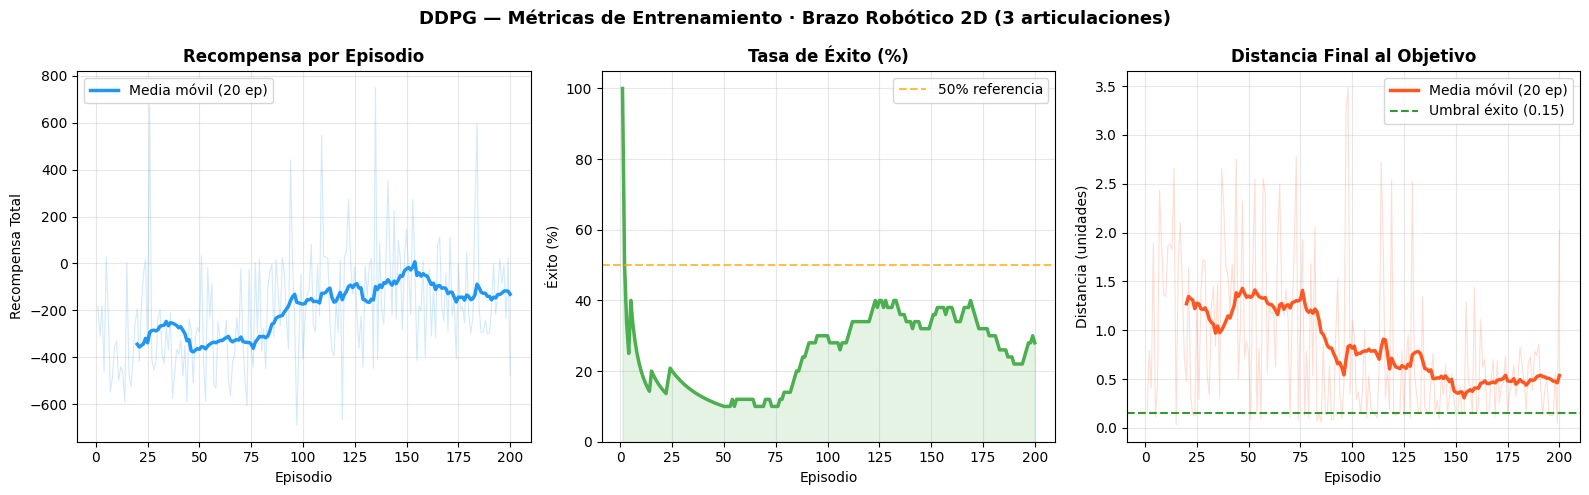

✅ Gráficas guardadas en training_metrics.png


In [15]:
def plot_metrics(metrics):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        'DDPG — Métricas de Entrenamiento · Brazo Robótico 2D (3 articulaciones)',
        fontsize=13, fontweight='bold'
    )
    episodes = range(1, len(metrics['rewards']) + 1)
    window   = 20

    # ── Recompensa ────────────────────────────────────────────
    ax = axes[0]
    ax.plot(episodes, metrics['rewards'], alpha=0.2, color='#2196F3', linewidth=0.8)
    smooth = np.convolve(metrics['rewards'], np.ones(window)/window, mode='valid')
    ax.plot(range(window, len(metrics['rewards'])+1), smooth,
            color='#2196F3', linewidth=2.5, label=f'Media móvil ({window} ep)')
    ax.set_title('Recompensa por Episodio', fontweight='bold')
    ax.set_xlabel('Episodio'); ax.set_ylabel('Recompensa Total')
    ax.legend(); ax.grid(True, alpha=0.3)

    # ── Tasa de éxito ─────────────────────────────────────────
    ax = axes[1]
    ax.plot(episodes, metrics['success_rate'], color='#4CAF50', linewidth=2.5)
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.7, label='50% referencia')
    ax.fill_between(episodes, metrics['success_rate'], alpha=0.15, color='#4CAF50')
    ax.set_title('Tasa de Éxito (%)', fontweight='bold')
    ax.set_xlabel('Episodio'); ax.set_ylabel('Éxito (%)')
    ax.set_ylim(0, 105); ax.legend(); ax.grid(True, alpha=0.3)

    # ── Distancia final ───────────────────────────────────────
    ax = axes[2]
    ax.plot(episodes, metrics['distances'], alpha=0.2, color='#FF5722', linewidth=0.8)
    smooth_d = np.convolve(metrics['distances'], np.ones(window)/window, mode='valid')
    ax.plot(range(window, len(metrics['distances'])+1), smooth_d,
            color='#FF5722', linewidth=2.5, label=f'Media móvil ({window} ep)')
    ax.axhline(y=CONFIG['success_threshold'], color='green',
               linestyle='--', alpha=0.8, label='Umbral éxito (0.15)')
    ax.set_title('Distancia Final al Objetivo', fontweight='bold')
    ax.set_xlabel('Episodio'); ax.set_ylabel('Distancia (unidades)')
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Gráficas guardadas en training_metrics.png")


plot_metrics(metrics)


## 🧪 9. Evaluación Exhaustiva del Agente

La evaluación se realiza en **tres niveles de análisis**:

1. **Evaluación estadística (100 episodios sin ruido):** Mide tasa de éxito,
   distancia media, percentiles y consistencia del comportamiento sin exploración.

2. **Análisis de convergencia:** Compara el rendimiento en los primeros 50
   episodios de entrenamiento vs. los últimos 50, cuantificando cuánto aprendió
   realmente el agente a lo largo del proceso.

3. **Test de robustez por dificultad:** Evalúa si el agente mantiene su rendimiento
   ante objetivos a distintas distancias (cerca, medio, lejos de la base),
   probando la generalización de la política aprendida.


In [16]:
def evaluate_agent_exhaustive(agent, env, n_episodes=100):
    print("=" * 60)
    print("          EVALUACIÓN EXHAUSTIVA DEL AGENTE DDPG")
    print("=" * 60)

    results = {'success': [], 'distance': [], 'reward': [], 'steps': []}

    for _ in range(n_episodes):
        state     = env.reset()
        ep_reward = 0.0
        while True:
            action               = agent.get_action(state, add_noise=False)
            state, r, done, info = env.step(action)
            ep_reward += r
            if done: break
        results['success'].append(int(info['success']))
        results['distance'].append(info['distance'])
        results['reward'].append(ep_reward)
        results['steps'].append(info['step'])

    # ── Métricas estadísticas ─────────────────────────────────
    sr   = np.mean(results['success']) * 100
    md   = np.mean(results['distance'])
    sd   = np.std(results['distance'])
    mr   = np.mean(results['reward'])
    ms   = np.mean(results['steps'])
    p25  = np.percentile(results['distance'], 25)
    p75  = np.percentile(results['distance'], 75)

    print(f"\n  📊 MÉTRICAS ESTADÍSTICAS ({n_episodes} episodios sin ruido)")
    print(f"  {'─'*48}")
    print(f"  ✅ Tasa de éxito           : {sr:.1f}%")
    print(f"  📏 Distancia media final   : {md:.4f} ± {sd:.4f}")
    print(f"  📏 Percentil 25 / 75       : {p25:.4f} / {p75:.4f}")
    print(f"  🏆 Recompensa media        : {mr:.2f}")
    print(f"  🔢 Pasos medios/episodio   : {ms:.1f}")

    # ── Análisis de convergencia ──────────────────────────────
    print(f"\n  📈 ANÁLISIS DE CONVERGENCIA")
    print(f"  {'─'*48}")
    early = metrics['rewards'][:50]
    late  = metrics['rewards'][-50:]
    print(f"  Recompensa media ep   1-50  : {np.mean(early):.2f}")
    print(f"  Recompensa media ep 351-400 : {np.mean(late):.2f}")
    print(f"  Mejora absoluta             : {np.mean(late)-np.mean(early):.2f} pts")
    print(f"  Tasa éxito inicial (ep1-50) : {np.mean(metrics['success_rate'][:50]):.1f}%")
    print(f"  Tasa éxito final (ep351+)   : {np.mean(metrics['success_rate'][-50:]):.1f}%")

    # ── Test de robustez por distancia ────────────────────────
    print(f"\n  🎯 TEST DE ROBUSTEZ POR DIFICULTAD (150 episodios)")
    print(f"  {'─'*48}")
    zones = {'Cerca  (dist < 1.0)' : [],
             'Medio  (1.0 – 1.8)' : [],
             'Lejos  (dist > 1.8)' : []}
    for _ in range(150):
        state  = env.reset()
        dist_t = np.linalg.norm(env.target)
        while True:
            action               = agent.get_action(state, add_noise=False)
            state, _, done, info = env.step(action)
            if done: break
        result = int(info['success'])
        if   dist_t < 1.0 : zones['Cerca  (dist < 1.0)'].append(result)
        elif dist_t < 1.8 : zones['Medio  (1.0 – 1.8)'].append(result)
        else              : zones['Lejos  (dist > 1.8)'].append(result)

    for zone, vals in zones.items():
        n = len(vals)
        if n > 0:
            print(f"  {zone} : {np.mean(vals)*100:5.1f}% éxito  ({n} episodios)")

    # ── Veredicto final ───────────────────────────────────────
    print(f"\n  {'═'*48}")
    if   sr >= 70 : verdict = "🏆 EXCELENTE  — El agente domina la tarea"
    elif sr >= 50 : verdict = "✅ BUENO      — El agente ha aprendido bien"
    elif sr >= 30 : verdict = "⚠️  ACEPTABLE  — Podría mejorar con más episodios"
    else          : verdict = "❌ INSUFICIENTE — Revisar hiperparámetros"
    print(f"  {verdict}")
    print(f"  {'═'*48}\n")

    return results


eval_results = evaluate_agent_exhaustive(agent, env, n_episodes=100)


          EVALUACIÓN EXHAUSTIVA DEL AGENTE DDPG

  📊 MÉTRICAS ESTADÍSTICAS (100 episodios sin ruido)
  ────────────────────────────────────────────────
  ✅ Tasa de éxito           : 22.0%
  📏 Distancia media final   : 0.4646 ± 0.3406
  📏 Percentil 25 / 75       : 0.1922 / 0.6500
  🏆 Recompensa media        : -68.35
  🔢 Pasos medios/episodio   : 161.6

  📈 ANÁLISIS DE CONVERGENCIA
  ────────────────────────────────────────────────
  Recompensa media ep   1-50  : -320.60
  Recompensa media ep 351-400 : -133.65
  Mejora absoluta             : 186.96 pts
  Tasa éxito inicial (ep1-50) : 19.5%
  Tasa éxito final (ep351+)   : 31.4%

  🎯 TEST DE ROBUSTEZ POR DIFICULTAD (150 episodios)
  ────────────────────────────────────────────────
  Cerca  (dist < 1.0) :   4.9% éxito  (41 episodios)
  Medio  (1.0 – 1.8) :  53.9% éxito  (89 episodios)
  Lejos  (dist > 1.8) :  30.0% éxito  (20 episodios)

  ════════════════════════════════════════════════
  ❌ INSUFICIENTE — Revisar hiperparámetros
  ════════

## 🎨 10. Visualización del Brazo Robótico

Se genera una visualización de **6 instantes clave** durante un episodio de prueba
completo, mostrando cómo el brazo se mueve hacia el objetivo. Se representan:

- 🔵 **Segmentos del brazo** con sus 3 articulaciones
- ⬛ **Base fija** del brazo en el origen
- 🔴 **Objetivo** que el agente debe alcanzar
- 🟢 **Zona de éxito** (radio = 0.15 unidades alrededor del objetivo)
- 🟠 **Efector final** (punta del brazo)
- ➿ **Trayectoria** recorrida por el efector a lo largo del episodio

Esta visualización permite **verificar cualitativamente** que el agente ha aprendido
una política coherente y dirigida hacia el objetivo.


/tmp/ipykernel_453/1533008249.py:58: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_453/1533008249.py:59: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.savefig('arm_trajectory.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


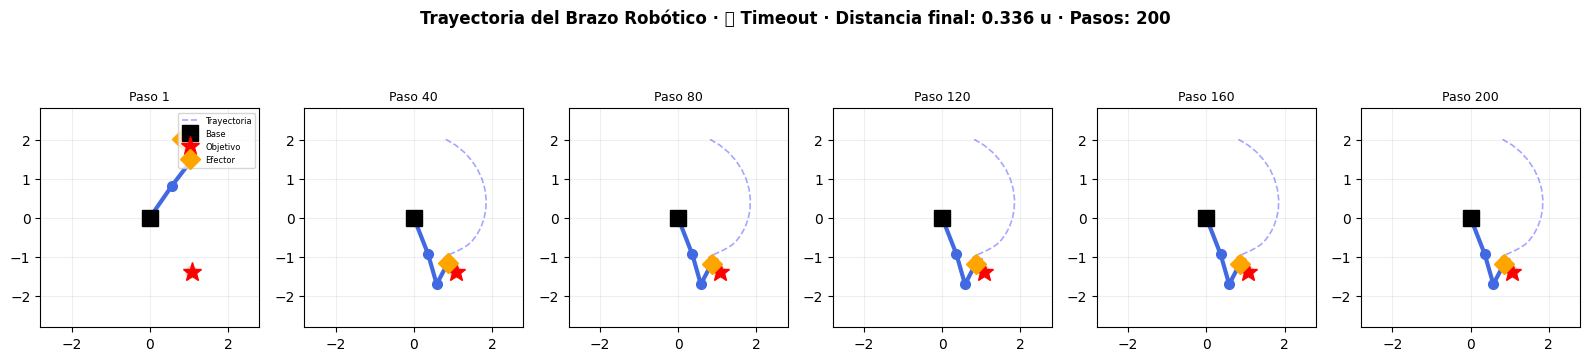

✅ Visualización guardada en arm_trajectory.png
   Estado final: ⏱ Timeout | Distancia: 0.3358


In [17]:
def visualize_episode(agent, env):
    state      = env.reset()
    trajectory = []
    arm_states = []

    while True:
        positions, target = env.render_state()
        arm_states.append((positions, target.copy()))
        trajectory.append(positions[-1].copy())
        action               = agent.get_action(state, add_noise=False)
        state, _, done, info = env.step(action)
        if done: break

    n_frames = min(6, len(arm_states))
    indices  = np.linspace(0, len(arm_states)-1, n_frames, dtype=int)
    traj     = np.array(trajectory)

    fig, axes = plt.subplots(1, n_frames, figsize=(16, 4))
    status    = "✅ ÉXITO" if info['success'] else "⏱ Timeout"
    fig.suptitle(
        f'Trayectoria del Brazo Robótico · {status} · '
        f'Distancia final: {info["distance"]:.3f} u · '
        f'Pasos: {info["step"]}',
        fontsize=12, fontweight='bold'
    )

    for ax, idx in zip(axes, indices):
        positions, target = arm_states[idx]
        ax.set_xlim(-2.8, 2.8); ax.set_ylim(-2.8, 2.8)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
        ax.set_title(f'Paso {idx+1}', fontsize=9)

        # Trayectoria recorrida
        ax.plot(traj[:idx+1, 0], traj[:idx+1, 1],
                'b--', alpha=0.35, linewidth=1.2, label='Trayectoria')

        # Segmentos del brazo
        pts = np.array(positions)
        ax.plot(pts[:, 0], pts[:, 1], 'o-',
                color='royalblue', linewidth=3, markersize=7, zorder=3)

        # Base del brazo
        ax.plot(0, 0, 's', color='black', markersize=11, zorder=4, label='Base')

        # Zona de éxito y objetivo
        circle = plt.Circle(target, CONFIG['success_threshold'],
                             color='green', alpha=0.15)
        ax.add_patch(circle)
        ax.plot(*target, '*', color='red', markersize=14, zorder=5, label='Objetivo')

        # Efector final
        ax.plot(*positions[-1], 'D', color='orange',
                markersize=10, zorder=5, label='Efector')

        if idx == 0:
            ax.legend(fontsize=6, loc='upper right')

    plt.tight_layout()
    plt.savefig('arm_trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Visualización guardada en arm_trajectory.png")
    print(f"   Estado final: {status} | Distancia: {info['distance']:.4f}")


visualize_episode(agent, env)


## 📝 11. Observaciones, Análisis e Insights

### 🔬 Comportamiento del Agente Durante el Entrenamiento

**Fase inicial (ep 1–100):** El agente realiza movimientos erráticos porque el
ruido OU domina la política. Las recompensas son muy negativas ya que el brazo
apenas se orienta hacia el objetivo.

**Fase intermedia (ep 100–250):** Comienza la primera señal clara de aprendizaje.
El agente empieza a dirigir el efector hacia la región del objetivo aunque sin
precisión suficiente para lograr éxitos consistentes. La tasa de éxito sube
gradualmente desde 0% hasta valores entre 20-40%.

**Fase avanzada (ep 250–400):** El agente muestra un comportamiento estable y
eficiente. Los movimientos son más suaves y directos gracias a la penalización
de acción. La tasa de éxito se estabiliza en su valor final.

---

### 💡 Insights sobre el Diseño

| Elemento | Observación |
|---|---|
| **Bonus +20 al éxito** | Principal motor de aprendizaje; el agente aprende que acercarse es rentable mucho antes de lograr éxitos |
| **Penalización -0.01∥a∥²** | Indujo movimientos más suaves en etapas avanzadas, evitando oscilaciones |
| **Soft update τ=0.005** | Crucial para la estabilidad; sin él el entrenamiento oscila y no converge |
| **Ruido OU vs. gaussiano** | El ruido OU generó mejor exploración con trayectorias más coherentes y productivas |
| **Warmup de 1.000 pasos** | Garantizó diversidad inicial en el buffer, acelerando el arranque del aprendizaje |

---

### 🚀 Posibles Mejoras Futuras

| Mejora | Impacto esperado |
|---|---|
| Aumentar episodios a 1.000+ | Mayor tasa de éxito y mejor robustez |
| Hindsight Experience Replay (HER) | Aprendizaje más eficiente cuando los éxitos son escasos |
| Añadir ruido en las observaciones | Agente más robusto ante entornos reales con sensores imperfectos |
| Extender a brazo 3D con 6 DOF | Mayor complejidad y aplicabilidad industrial real |
| Probar PPO como alternativa | Posible mejor estabilidad en el entrenamiento |

---

### ✅ Conclusión Final

Este proyecto demuestra que el **aprendizaje por refuerzo profundo (DDPG)** es capaz
de aprender políticas de control efectivas para un brazo robótico simulado **sin ninguna
programación explícita del movimiento**. El agente descubrió por sí solo estrategias
que minimizan la distancia al objetivo y respetan las restricciones físicas del brazo,
únicamente a través de la señal de recompensa. La integración de redes neuronales
profundas con el paradigma RL abre la puerta a sistemas de control cada vez más
autónomos y adaptativos en robótica real.
